# Análise de Dados e Modelo Preditivo: Naufragio Titanic

## Carregamento dos Dados

Os dados foram carregados diretamente de um arquivo CSV que se encontra no Google Driver

In [ ]:
#Importando bibliotecas necessarias
import shap
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report # Added classification_report import here
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV

In [ ]:
#Carregando os dados
dados = pd.read_csv('/content/drive/MyDrive/machine_learning/titanic (1).csv')

In [ ]:
#Verificar valores ausentes
print(dados.isnull().sum())

#Verificar as primeiras linhas dos dados
dados.head()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## Descrição dos dados

Os dados incluem a seguintes variaveis

  * **Survived:** Sobrevivência
  * **Pclass**: Classe da passagem (Status socioeconomico)
  * **Name:** Nome do passageiro
  * **Sex:** Sexo (male = Masculino, female= Feminino)
  * **Age:** Idade do passageiro (Idade fracionada se for menor que 1. Estimada, no formato xx,5)
  * **Siblings/Spouses Aboard:** Contagem de relaçoes familiares (irmão(ã) ou conjugue)
  * **Parents/Children Aboard:** Contagem de relação paterna ou materna (mãe, pai, filho(a))
  * **Fare:** Tarifa do passageiro

## Estatisticas Descritivas

In [ ]:
#Estatisticas gerais do conjunto de dados
dados.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


## Análise de Distribuições

A seguir, graficos das distribuições dos atributos numericos e categoricos

In [ ]:
#Variáveis numéricas
var_num = ['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']

#Variaveis Categoricas
var_cat = ['Survived', 'Pclass', 'Sex']

In [ ]:
#Criando uma função para receber as variaveis e plotar os graficos
def plotar_hist(variaveis, fig, axes):
  for i, col in enumerate(variaveis):
    ax = axes[i//2,i%2]

    if(variaveis[col].dtype == 'object' or variaveis[col].nunique() < 4):

      variaveis[col].value_counts().plot(kind='bar', ax=ax, color='blue', edgecolor='black')
      ax.set_title(f'Distribuição de {col}')
      ax.set_ylabel('Frequência')
    else:
      ax.hist(variaveis[col], bins=10, color='red', edgecolor='black', )
      ax.set_title(f'Distribuição de {col}')
      ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

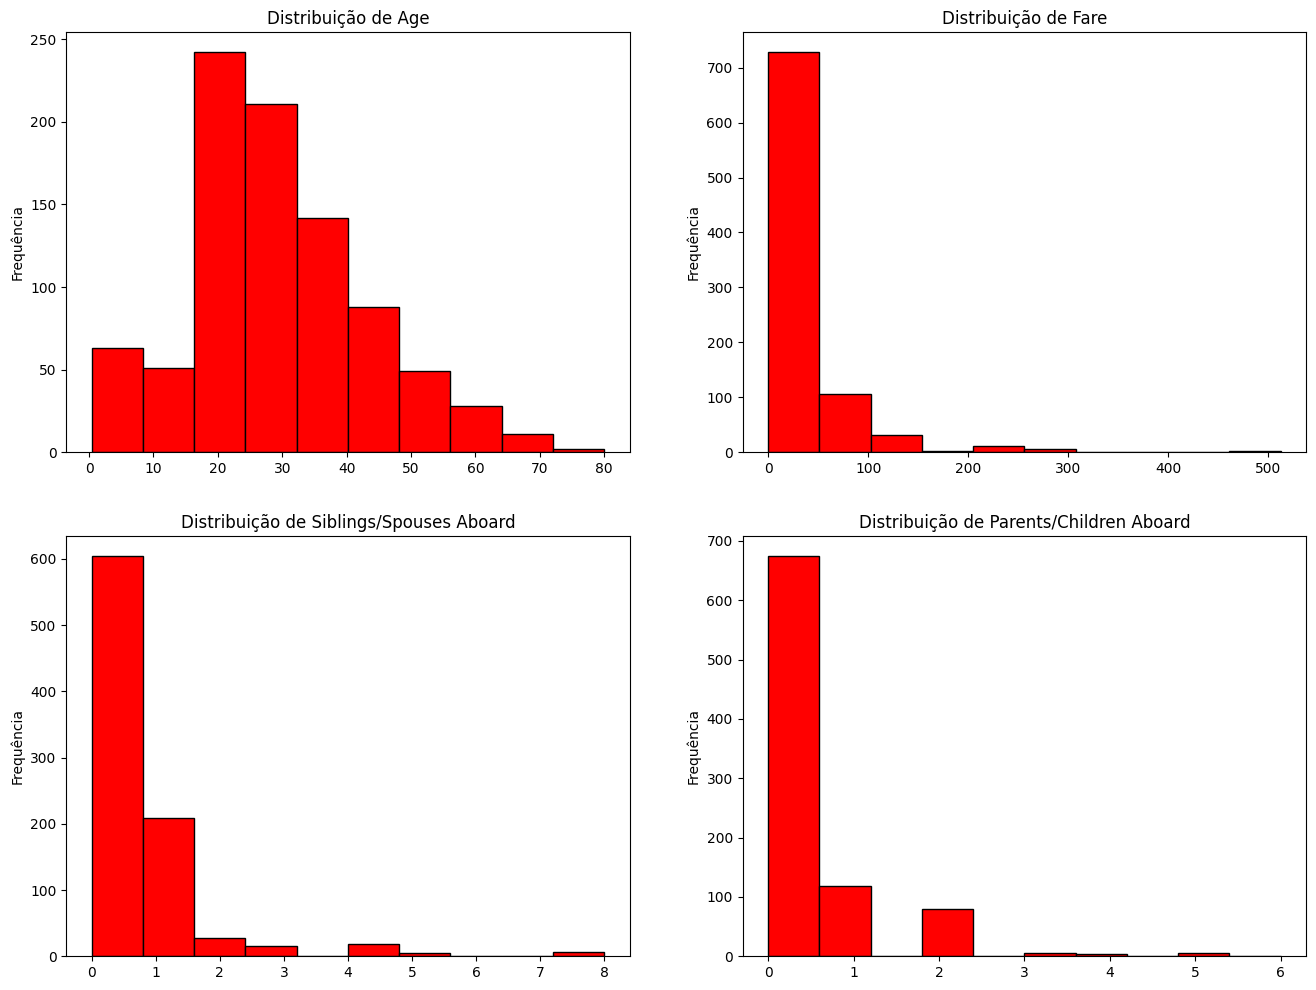

In [ ]:
#Plotar distribuicoes numericas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

plotar_hist(dados[var_num], fig, axes)

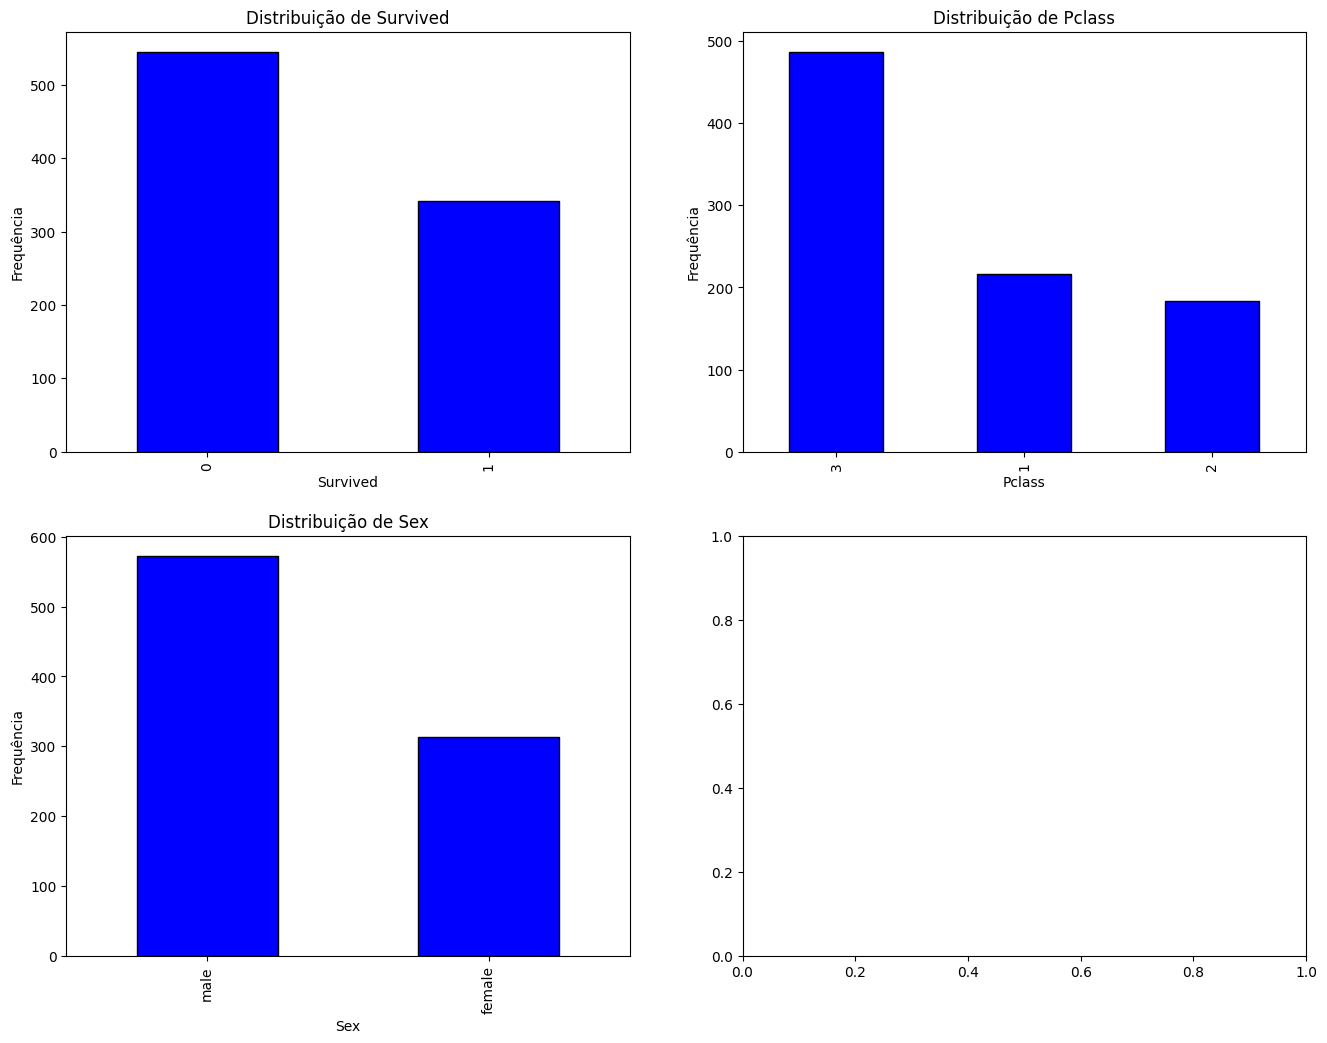

In [ ]:
#Plotar distribuicoes categoricas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

plotar_hist(dados[var_cat], fig, axes)

## Análise Exploratoria

In [ ]:
# @title Criando a estrutura para a tabela/grafico de distribuição de sobreviventes/mortos
#Coletando a frequencia de mortes por sexo e em percentual
frequencia_mortes_sexo = pd.crosstab(dados['Sex'], dados['Survived'], margins=True, margins_name="Total")
frequencia_mortes_sexo_sem_total = frequencia_mortes_sexo.iloc[:-1, :-1]
frequencia_mortes_sexo_perc = pd.crosstab(dados['Sex'], dados['Survived'], normalize=True, margins=True, margins_name="Total %") * 100
frequencia_mortes_sexo_perc_sem_total = frequencia_mortes_sexo_perc.iloc[:-1, :-1]

#Separando a frequencias por sexo em variaveis
mulher_obito = frequencia_mortes_sexo.loc['female'][0]
homem_obito = frequencia_mortes_sexo.loc['male'][0]

mulher_sob =  frequencia_mortes_sexo.loc['female'][1]
homem_sob = frequencia_mortes_sexo.loc['male'][1]

mortos_mulheres = round((mulher_obito / (mulher_obito + mulher_sob)) *100, 2)
mortos_homens = round((homem_obito / (homem_obito + homem_sob)) *100, 2)

sobrev_mulheres = round((mulher_sob / (mulher_obito + mulher_sob)) *100,2)
sobrev_homens = round((homem_sob / (homem_obito + homem_sob)) *100,2)

mortos_por_sexo = [mortos_mulheres, mortos_homens]
sobrev_por_sexo = [sobrev_mulheres, sobrev_homens]

#Criando a estrutura para a tabela de sobreviventes
linha_total = {'Mortos': frequencia_mortes_sexo.loc['Total'][0],'Sobreviventes': frequencia_mortes_sexo.loc['Total'][1],'Mortos %': "-",'Sobreviventes %': "-", 'Total %': "-"}

frequencia_mortes_sexo_combinado = pd.concat([frequencia_mortes_sexo_sem_total, frequencia_mortes_sexo_perc_sem_total.round(2)], axis=1).astype('object')
frequencia_mortes_sexo_combinado['Total %'] = frequencia_mortes_sexo_perc['Total %'].round(2)
frequencia_mortes_sexo_combinado.columns = ['Mortos', 'Sobreviventes', 'Mortos %', 'Sobreviventes %','Total %']
frequencia_mortes_sexo_combinado["Mortos por sexo %"] = mortos_por_sexo
frequencia_mortes_sexo_combinado["Sobreviventes por sexo %"] = sobrev_por_sexo
frequencia_mortes_sexo_combinado.loc["Total", "Total"] = frequencia_mortes_sexo.loc["Total", "Total"]
frequencia_mortes_sexo_combinado["Total"] = frequencia_mortes_sexo["Total"].reindex(frequencia_mortes_sexo_combinado.index)
frequencia_mortes_sexo_combinado.index = ['Mulher', 'Homem','Total']

frequencia_mortes_sexo_combinado = frequencia_mortes_sexo_combinado.astype('object')

frequencia_mortes_sexo_combinado = frequencia_mortes_sexo_combinado[[
    "Mortos",
    "Sobreviventes",
    "Mortos por sexo %",
    "Sobreviventes por sexo %",
    "Mortos %",
    "Sobreviventes %",
    "Total",
    "Total %"
]]

#Adiciona a linha total na tabela
for coluna, valor in linha_total.items():
  frequencia_mortes_sexo_combinado.at['Total', coluna] = valor

frequencia_mortes_sexo_combinado.fillna("-", inplace=True)

#Dividindo passageiros com parentes e que não tem parentes
dados_com_parentes = dados[dados['Parents/Children Aboard'] > 0]
dados_sem_parentes = dados[dados['Parents/Children Aboard'] == 0]


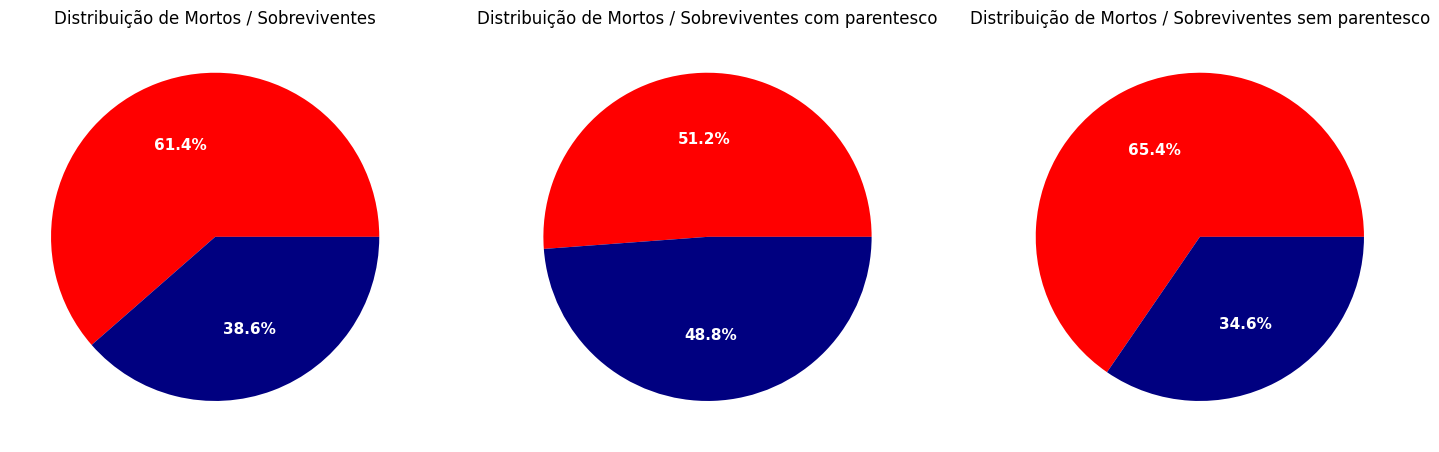

,Mortos,Sobreviventes,Mortos por sexo %,Sobreviventes por sexo %,Mortos %,Sobreviventes %,Total,Total %
Mulher,81,233,25.8,74.2,9.13,26.27,314,35.4
Homem,464,109,80.98,19.02,52.31,12.29,573,64.6
Total,545,342,-,-,-,-,887,-


In [ ]:
#Plotando os graficos de distribuição de sobreviventes/mortos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10))
cores = ['red','navy']
font = {'color':'white','fontsize':11, 'weight':'bold'}


ax = axes[0]

ax.pie(dados['Survived'].value_counts(), labels=['Mortos', 'Sobreviventes'], autopct='%1.1f%%', colors=cores, textprops=font)
ax.set_title('Distribuição de Mortos / Sobreviventes', fontsize=12)

ax = axes[1]

ax.pie(dados_com_parentes['Survived'].value_counts(), labels=['Mortos', 'Sobreviventes'], autopct='%1.1f%%',colors=cores, textprops=font)
ax.set_title('Distribuição de Mortos / Sobreviventes com parentesco',fontsize=12)

ax = axes[2]

ax.pie(dados_sem_parentes['Survived'].value_counts(), labels=['Mortos', 'Sobreviventes'], autopct='%1.1f%%',colors=cores, textprops=font)
ax.set_title('Distribuição de Mortos / Sobreviventes sem parentesco', fontsize=12)

plt.show()

#Visualizando a tabela de distribuição de sobreviventes/mortos
frequencia_mortes_sexo_combinado


In [ ]:
# @title Criando a estrutura para a tabela/grafico de distribuição de sobreviventes/mortos por classe e sexo
#Coletando os dados dos passageiros, sobreviventes e mortos por classe e sexo
mortes_p1_m = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 1) & (dados['Sex'] == 'male')].shape[0]
mortes_p2_m = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 2) & (dados['Sex'] == 'male')].shape[0]
mortes_p3_m = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 3) & (dados['Sex'] == 'male')].shape[0]

mortes_p1_f = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 1) & (dados['Sex'] == 'female')].shape[0]
mortes_p2_f = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 2) & (dados['Sex'] == 'female')].shape[0]
mortes_p3_f = dados[(dados['Survived'] == 0) & (dados['Pclass'] == 3) & (dados['Sex'] == 'female')].shape[0]

sobreviventes_p1_m = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 1) & (dados['Sex'] == 'male')].shape[0]
sobreviventes_p2_m = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 2) & (dados['Sex'] == 'male')].shape[0]
sobreviventes_p3_m = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 3) & (dados['Sex'] == 'male')].shape[0]

sobreviventes_p1_f = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 1) & (dados['Sex'] == 'female')].shape[0]
sobreviventes_p2_f = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 2) & (dados['Sex'] == 'female')].shape[0]
sobreviventes_p3_f = dados[(dados['Survived'] == 1) & (dados['Pclass'] == 3) & (dados['Sex'] == 'female')].shape[0]

classes = sorted(dados['Pclass'].unique())
str_classes = [str(n) for n in classes]
mortes_m = [mortes_p1_m, mortes_p2_m, mortes_p3_m]
mortes_f = [mortes_p1_f, mortes_p2_f, mortes_p3_f]
sobreviventes_m = [sobreviventes_p1_m, sobreviventes_p2_m, sobreviventes_p3_m]
sobreviventes_f = [sobreviventes_p1_f, sobreviventes_p2_f, sobreviventes_p3_f]

#Criando tabela de classe por sobreviventes/mortos
frequencia_mortes_classe = pd.crosstab(dados['Pclass'], dados['Survived'], margins=True, margins_name="Total")
frequencia_mortes_classe_sem_total = frequencia_mortes_classe.iloc[:-1, :-1]

#Criando tabela de classe por sobreviventes/mortos em percentual
frequencia_mortes_classe_perc = pd.crosstab(dados['Pclass'], dados['Survived'], normalize=True, margins=True, margins_name="Total %") * 100
frequencia_mortes_classe_perc_sem_total = frequencia_mortes_classe_perc.iloc[:-1, :-1]

nova_linha = {'Mortos': frequencia_mortes_classe.loc['Total'][0],'Sobreviventes': frequencia_mortes_classe.loc['Total'][1],'Mortos %': "-",'Sobreviventes %': "-", 'Total %': "-"}

#Separando a frequencias por classe em variaveis
classe1_obito = frequencia_mortes_classe.loc[1][0]
classe2_obito = frequencia_mortes_classe.loc[2][0]
classe3_obito = frequencia_mortes_classe.loc[3][0]

classe1_sob = frequencia_mortes_classe.loc[1][1]
classe2_sob = frequencia_mortes_classe.loc[2][1]
classe3_sob = frequencia_mortes_classe.loc[3][1]

mortos_por_classe1 = round((classe1_obito / (classe1_obito + classe1_sob)) *100, 2)
mortos_por_classe2 = round((classe2_obito / (classe2_obito + classe2_sob)) *100, 2)
mortos_por_classe3 = round((classe3_obito / (classe3_obito + classe3_sob)) *100, 2)

sob_por_classe1 = round((classe1_sob / (classe1_obito + classe1_sob)) *100,2)
sob_por_classe2 = round((classe2_sob / (classe2_obito + classe2_sob)) *100,2)
sob_por_classe3 = round((classe3_sob / (classe3_obito + classe3_sob)) *100,2)

mortos_por_classe = [mortos_por_classe1, mortos_por_classe2, mortos_por_classe3]
sobrev_por_classe = [sob_por_classe1, sob_por_classe2, sob_por_classe3]

#Criando a estrutura para a tabela de distribuição de sobreviventes/mortos por classe e sexo
frequencia_mortes_classe_perc_combinado = pd.concat([frequencia_mortes_classe_sem_total, frequencia_mortes_classe_perc_sem_total.round(2)], axis=1).astype('object')
frequencia_mortes_classe_perc_combinado['Total %'] = frequencia_mortes_classe_perc['Total %'].round(2)
frequencia_mortes_classe_perc_combinado.columns = ['Mortos', 'Sobreviventes', 'Mortos %', 'Sobreviventes %', "Total %"]
frequencia_mortes_classe_perc_combinado["Mortos por classe %"] = mortos_por_classe
frequencia_mortes_classe_perc_combinado["Sobreviventes por classe %"] = sobrev_por_classe
frequencia_mortes_classe_perc_combinado.loc["Total", "Total"] = frequencia_mortes_classe.loc["Total", "Total"]
frequencia_mortes_classe_perc_combinado["Total"] = frequencia_mortes_classe["Total"].reindex(frequencia_mortes_classe_perc_combinado.index)
frequencia_mortes_classe_perc_combinado.index = ['Classe 1', 'Classe 2', 'Classe 3', 'Total']

frequencia_mortes_classe_perc_combinado = frequencia_mortes_classe_perc_combinado.astype('object')

#Adicionando a linha total a tabela
for coluna, valor in nova_linha.items():
  frequencia_mortes_classe_perc_combinado.at['Total', coluna] = valor

frequencia_mortes_classe_perc_combinado = frequencia_mortes_classe_perc_combinado[[
    "Mortos",
    "Sobreviventes",
    "Mortos por classe %",
    "Sobreviventes por classe %",
    "Mortos %",
    "Sobreviventes %",
    "Total",
    "Total %"
]]
frequencia_mortes_classe_perc_combinado.fillna("-", inplace=True)
frequencia_mortes_classe_perc_combinado.index.name = 'Classe'

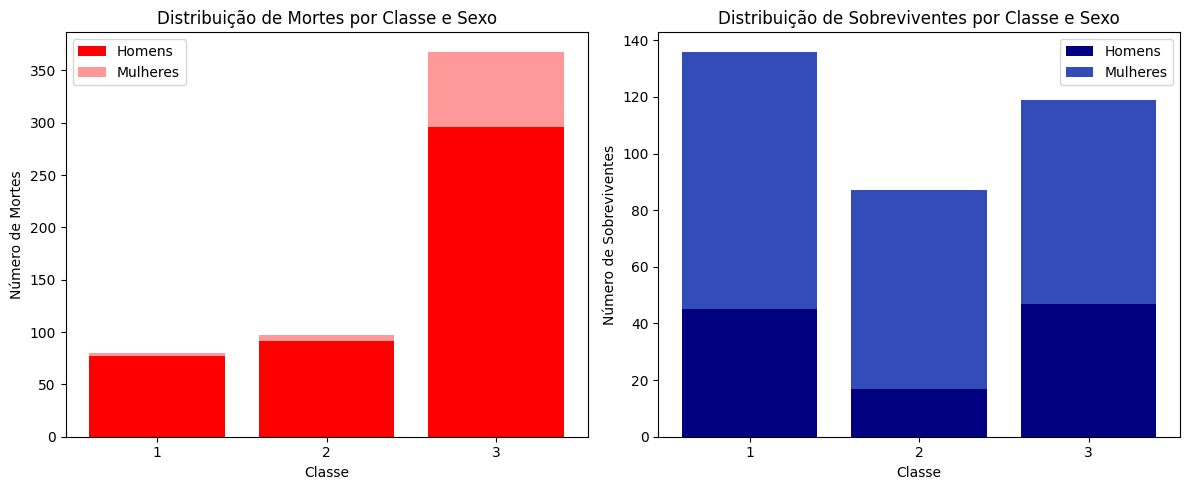

,Mortos,Sobreviventes,Mortos por classe %,Sobreviventes por classe %,Mortos %,Sobreviventes %,Total,Total %
Classe,,,,,,,,
Classe 1,80,136,37.04,62.96,9.02,15.33,216,24.35
Classe 2,97,87,52.72,47.28,10.94,9.81,184,20.74
Classe 3,368,119,75.56,24.44,41.49,13.42,487,54.9
Total,545,342,-,-,-,-,887,-


In [ ]:
#Plotar grafico de distribuição de sobreviventes/mortos por classe e sexo
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax = axes[0]

ax.bar(str_classes, mortes_m, label='Homens', color=cores[0])
ax.bar(str_classes, mortes_f, bottom=mortes_m ,label='Mulheres', color='#FF9999')
ax.set_xlabel('Classe')
ax.set_ylabel('Número de Mortes')
ax.set_title('Distribuição de Mortes por Classe e Sexo')
ax.legend()

ax = axes[1]

ax.bar(str_classes, sobreviventes_m, label='Homens', color=cores[1])
ax.bar(str_classes, sobreviventes_f, bottom=sobreviventes_m ,label='Mulheres',color='#344CB7')
ax.set_xlabel('Classe')
ax.set_ylabel('Número de Sobreviventes')
ax.set_title('Distribuição de Sobreviventes por Classe e Sexo')
ax.legend()

plt.tight_layout()
plt.show()

#Visualizando tabela de distribuição de sobreviventes/mortos por classe e sexo
frequencia_mortes_classe_perc_combinado

In [ ]:
# @title Criando a estrutura para tabela/grafico de distribuição de mortos por faixa etaria

#Criando as classes para faixa de etaria
classes = [0,10,20,30,40,50,60,70,80]

#Descrição de cada faixa
labels = [
    'Abaixo de 10 anos',
    'Entre 10 e 20 anos',
    'Entre 20 e 30 anos',
    'Entre 30 e 40 anos',
    'Entre 40 e 50 anos',
    'Entre 50 e 60 anos',
    'Entre 60 e 70 anos',
    'Acima de 70 anos'
]

#Frequencia de sobreviventes por idade
faixa_etaria_sobrev = pd.value_counts (pd.cut(x=dados[dados['Survived'] == 1]['Age'],
                        bins=classes,
                        labels=labels,
                        include_lowest=True))

#Frequencia de mortos por idade
faixa_etaria_obito = pd.value_counts (pd.cut(x=dados[dados['Survived'] == 0]['Age'],
                        bins=classes,
                        labels=labels,
                        include_lowest=True))

#Porcentagem de sobreviventes e mortos
mortos_norm = round(faixa_etaria_obito / faixa_etaria_obito.sum() * 100,2)
vivos_norm = round(faixa_etaria_sobrev / faixa_etaria_sobrev.sum() * 100,2)

#Porcentagem de sobreviventes e mortos por faixa etaria
mortos_por_faixa = round((faixa_etaria_obito / (faixa_etaria_obito + faixa_etaria_sobrev)) *100, 2)
sobrev_por_faixa = round((faixa_etaria_sobrev / (faixa_etaria_obito + faixa_etaria_sobrev)) *100, 2)

#Criando a estrutura para a tabela de distribuição de sobreviventes/mortos por faixa etaria
dist_freq_vivos_mortos_etaria = pd.DataFrame({'Mortos': faixa_etaria_obito, 'Sobreviventes': faixa_etaria_sobrev, 'Mortos por faixa %': mortos_por_faixa, 'Sobreviventes por faixa %': sobrev_por_faixa ,'Mortos %': mortos_norm, 'Sobreviventes %':vivos_norm, 'Total': faixa_etaria_obito + faixa_etaria_sobrev, 'Total %': round(mortos_norm + vivos_norm,2)})
total_linha = {'Mortos': faixa_etaria_obito.sum(), 'Sobreviventes': faixa_etaria_sobrev.sum(), 'Mortos por faixa %': "-", 'Sobreviventes por faixa %': "-", 'Mortos %': "-", 'Sobreviventes %': "-", 'Total':  faixa_etaria_obito.sum() + faixa_etaria_sobrev.sum(), 'Total %':"-"}
dist_freq_vivos_mortos_etaria.sort_index(inplace=True)
dist_freq_vivos_mortos_etaria.loc['Total'] = total_linha
dist_freq_vivos_mortos_etaria.index.name = 'Faixa Etária'

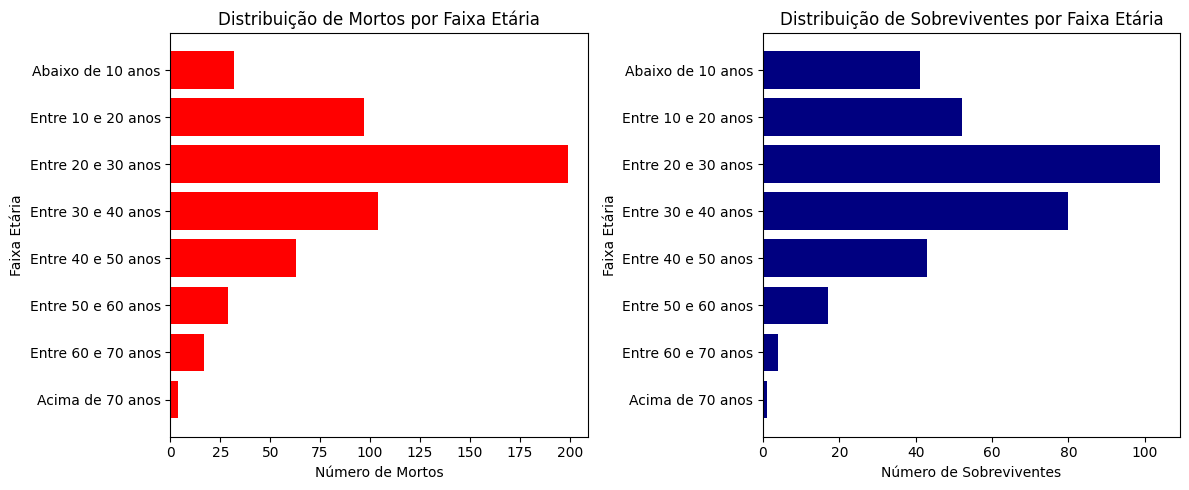

,Mortos,Sobreviventes,Mortos por faixa %,Sobreviventes por faixa %,Mortos %,Sobreviventes %,Total,Total %
Faixa Etária,,,,,,,,
Abaixo de 10 anos,32,41,43.84,56.16,5.87,11.99,73,17.86
Entre 10 e 20 anos,97,52,65.1,34.9,17.8,15.2,149,33.0
Entre 20 e 30 anos,199,104,65.68,34.32,36.51,30.41,303,66.92
Entre 30 e 40 anos,104,80,56.52,43.48,19.08,23.39,184,42.47
Entre 40 e 50 anos,63,43,59.43,40.57,11.56,12.57,106,24.13
Entre 50 e 60 anos,29,17,63.04,36.96,5.32,4.97,46,10.29
Entre 60 e 70 anos,17,4,80.95,19.05,3.12,1.17,21,4.29
Acima de 70 anos,4,1,80.0,20.0,0.73,0.29,5,1.02
Total,545,342,-,-,-,-,887,-


In [ ]:
#Plotar grafico de distribuição de sobreviventes/mortos por faixa etaria
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
dados_sem_total = dist_freq_vivos_mortos_etaria.loc[dist_freq_vivos_mortos_etaria.index != 'Total']


ax = axes[0]

ax.barh(dados_sem_total.index, dados_sem_total['Mortos'], color=cores[0])
ax.set_xlabel('Número de Mortos')
ax.set_ylabel('Faixa Etária')
ax.set_title('Distribuição de Mortos por Faixa Etária')
ax.invert_yaxis()

ax = axes[1]

ax.barh(dados_sem_total.index, dados_sem_total['Sobreviventes'], color=cores[1])
ax.set_xlabel('Número de Sobreviventes')
ax.set_ylabel('Faixa Etária')
ax.set_title('Distribuição de Sobreviventes por Faixa Etária')
ax.invert_yaxis()


plt.tight_layout()
plt.show()

#Visualizar tabela de distribuição de sobreviventes/mortos por faixa etaria
dist_freq_vivos_mortos_etaria

In [ ]:
#Converter variáveis categóricas para numéricas
label_encoder = LabelEncoder()

for coluna in ['Pclass','Sex']:
  dados[coluna] = label_encoder.fit_transform(dados[coluna])

In [ ]:
#Selecionando as variaveis para analisar na correlação
dados_cor = dados[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']]

In [ ]:
#Criando a correlação entre as variaveis
correlacao = dados_cor.corr()

,Survived,Pclass,Sex,Age,Fare,Siblings/Spouses Aboard,Parents/Children Aboard
Survived,1.000000,-0.336528,-0.542152,-0.059665,0.256179,-0.037082,0.080097
Pclass,-0.336528,1.000000,0.129507,-0.391492,-0.548919,0.085026,0.020252
Sex,-0.542152,0.129507,1.000000,0.091875,-0.181137,-0.113249,-0.244337
Age,-0.059665,-0.391492,0.091875,1.000000,0.112329,-0.297669,-0.193741
Fare,0.256179,-0.548919,-0.181137,0.112329,1.000000,0.158839,0.215470
Siblings/Spouses Aboard,-0.037082,0.085026,-0.113249,-0.297669,0.158839,1.000000,0.414244
Parents/Children Aboard,0.080097,0.020252,-0.244337,-0.193741,0.215470,0.414244,1.000000


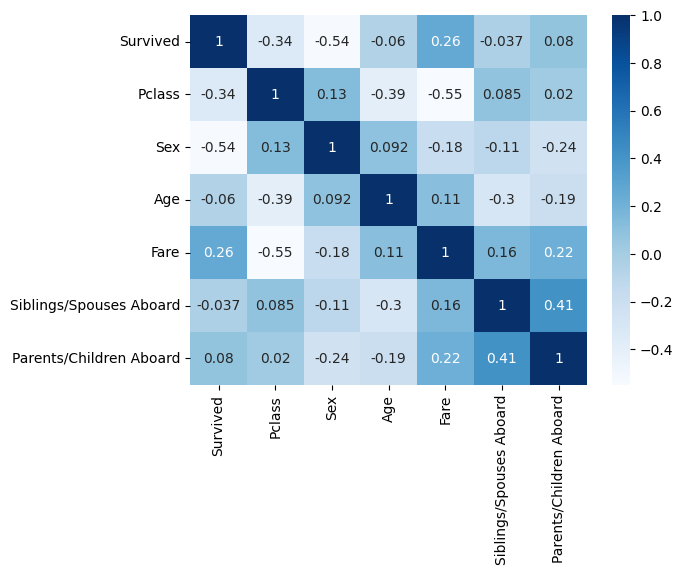

In [ ]:
#Visualizando a correlação e o grafico
sns.heatmap(correlacao, annot=True, cmap='Blues')
correlacao

## Preparação dos dados para modelagem

In [ ]:
#Separar variáveis preditoras (x) e alvo (y)
X = dados[['Pclass', 'Sex', 'Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard']]
y = dados['Survived']

#Dividir os dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Treinamento de modelos preditivos

In [ ]:
desempenhos = {}



---


**Primeiro modelo**

> Decision Tree Classifier

In [ ]:
#Treinar o modelo usando Decision Tree Classifier
modelo_1 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
modelo_1.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [ ]:
#Capturando as variaveis mais "importantes" que foram usadas na criação da arvore de decisão
importancia = modelo_1.feature_importances_
variaveis = list(zip(X.columns, importancia))
variaveis.sort(key=lambda x: x[1], reverse=True)

for coluna, importancia in variaveis:
  print(f'{coluna}: {importancia}')


Sex: 0.581506836728489
Pclass: 0.22528104506511004
Fare: 0.09464523738642575
Age: 0.07525302248957731
Siblings/Spouses Aboard: 0.023313858330397848
Parents/Children Aboard: 0.0


In [ ]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Método (RFE) para selecionar as melhores features (variaves independentes/atributos)
parametros = {'n_features_to_select': range(1, X.shape[1] + 1)}
rfe = RFE(modelo_1)

#Treinamento do modelo k vezes, testando todas as combinações possiveis de valores, calculando a performance média do modelo em cada combinação
grid = GridSearchCV(rfe, parametros, cv=kf)
grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RFE(estimator=DecisionTreeClassifier(criterion='entropy',
                                                            max_depth=3,
                                                            random_state=42)),
             param_grid={'n_features_to_select': range(1, 7)})

In [ ]:
#Mostrando em tela a quantidade certa de variaveis para o nosso modelo
print("Melhor numero de variaveis: ", grid.best_params_['n_features_to_select'])

Melhor numero de variaveis:  5


In [ ]:
#Visualizando as melhores variaveis para o nosso modelo.
for i, coluna in zip(range(X.shape[1]), X.columns):
  print(f'{coluna} selecionado={grid.best_estimator_.support_[i]} posição={grid.best_estimator_.ranking_[i]}')

Pclass selecionado=True posição=1
Sex selecionado=True posição=1
Age selecionado=True posição=1
Fare selecionado=True posição=1
Siblings/Spouses Aboard selecionado=True posição=1
Parents/Children Aboard selecionado=False posição=2


In [ ]:
#Previsão do modelo 1
previsao_modelo_1 = modelo_1.predict(X_test)

In [ ]:
#Avaliação do modelo 1
print(accuracy_score(y_test, previsao_modelo_1))

0.7865168539325843


In [ ]:
desempenhos['Decision Tree Classifier'] = accuracy_score(y_test, previsao_modelo_1)



---


**Segundo modelo**

> Logistic Regression

In [ ]:
#Usando somente os atributos que foram selecionados acima na visualização das melhores 'features'
X = dados[['Pclass', 'Sex', 'Age', 'Fare','Siblings/Spouses Aboard']]
y = dados['Survived']

#Dividir os dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Treinar o modelo usando Logistic Regression
modelo_2 = LogisticRegression()
modelo_2.fit(X_train,y_train)

LogisticRegression()

In [ ]:
#Previsão do modelo 2
previsao_modelo_2 = modelo_2.predict(X_test)

In [ ]:
#Avaliação do modelo 2
print(accuracy_score(y_test, previsao_modelo_2))

0.7471910112359551


In [ ]:
desempenhos['Logistic Regression'] = accuracy_score(y_test, previsao_modelo_2)



---


**Terceiro modelo**

> KNeighborsClassifier

In [ ]:
#Devido a toda a analise exploratoria, usaremos aqui somente os atributos que possui muito impacto para sobrevivencia ou não do passageiro
X = dados[['Pclass', 'Sex', 'Age']]
y = dados['Survived']

#Dividir os dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Vamos estabelecer e testar qual o melhor valor de k, para usarmos em nosso modelo.
valores = {}
k = 1
vencedor = []

#Treinar o modelo usando KNeighborsClassifier
while k <= 25:
  modelo_3 = KNeighborsClassifier(n_neighbors=k)
  modelo_3.fit(X_train, y_train)
  previsao_modelo_3 = modelo_3.predict(X_test)
  acertos_knn = accuracy_score(y_test, previsao_modelo_3)
  valores[k] = round(acertos_knn,4)
  k += 1

#Visualização do melhor valor de k e o melhor desempenho do modelo
print(valores)
valor_k = max(valores, key=valores.get)
print("Valor do k é ",valor_k," e porcentagem de acertos",valores[valor_k])

{1: 0.7135, 2: 0.7753, 3: 0.736, 4: 0.7528, 5: 0.7584, 6: 0.7697, 7: 0.7697, 8: 0.7865, 9: 0.7472, 10: 0.7697, 11: 0.764, 12: 0.764, 13: 0.7809, 14: 0.7584, 15: 0.7865, 16: 0.7978, 17: 0.7865, 18: 0.7978, 19: 0.7809, 20: 0.7753, 21: 0.7809, 22: 0.7697, 23: 0.7921, 24: 0.764, 25: 0.7809}
Valor do k é  16  e porcentagem de acertos 0.7978


In [ ]:
desempenhos['KNeighborsClassifier'] = valores[valor_k]

## Visualização dos desempenho dos modelos

In [ ]:
print("Matriz de Confusão - Decision Tree Classifier")
print(confusion_matrix(y_test, previsao_modelo_1))
print("\nRelatório de Classificação - Decision Tree Classifier")
print(classification_report(y_test, previsao_modelo_1))

print('\n')

print("Matriz de Confusão - Logistic Regression")
print(confusion_matrix(y_test, previsao_modelo_2))
print("\nRelatório de Classificação - Logistic Regression	")
print(classification_report(y_test, previsao_modelo_2))

print('\n')

print("Matriz de Confusão - KNeighborsClassifier")
print(confusion_matrix(y_test, previsao_modelo_3))
print("\nRelatório de Classificação - KNeighborsClassifier	")
print(classification_report(y_test, previsao_modelo_3))


Matriz de Confusão - Decision Tree Classifier
[[98 13]
 [25 42]]

Relatório de Classificação - Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       111
           1       0.76      0.63      0.69        67

    accuracy                           0.79       178
   macro avg       0.78      0.75      0.76       178
weighted avg       0.78      0.79      0.78       178



Matriz de Confusão - Logistic Regression
[[95 16]
 [29 38]]

Relatório de Classificação - Logistic Regression	
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       111
           1       0.70      0.57      0.63        67

    accuracy                           0.75       178
   macro avg       0.73      0.71      0.72       178
weighted avg       0.74      0.75      0.74       178



Matriz de Confusão - KNeighborsClassifier
[[103   8]
 [ 31  36]]

Relatório de Classificação - KNeighborsClassi

In [ ]:
result_modelos = pd.DataFrame.from_dict(desempenhos, orient='index', columns=['Acurácia'])
result_modelos.sort_values(by='Acurácia', ascending=False, inplace=True)
result_modelos.round(4)

,Acurácia
KNeighborsClassifier,0.7978
Decision Tree Classifier,0.7865
Logistic Regression,0.7472


### Conclusão
Analisando os resultados dos três modelos preditivos para estimar a sobrevivência dos passageiros no naufrágio do Titanic, é possível, com base nas métricas de avaliação apresentadas, identificar qual modelo demonstrou o melhor desempenho.

Crédito: https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/problem12.html